# Pha T.3b — PCA đặc trưng theo từng khối mạng 

Mục đích:
1. PCA đặc trưng ở từng khối (Input, Block 1, Block 2, Block 3) trên dữ liệu synthetic, tô theo cường độ ghép nối thật `c` — kiểm tra mạng có học biểu diễn phản ánh đúng cấu trúc dữ liệu không.
2. PCA joint vs marginal — đúng 2 loại mẫu mà chặn dưới Donsker-Varadhan yêu cầu mạng phân biệt được.
3. Chiếu dữ liệu THẬT (Fantasia) vào đúng không gian PCA đã fit trên synthetic (không fit lại) — hình "gap" trực diện cho domain-generalization failure đã thấy ở Pha S.

Không dùng lại `estimate()` vì cần giữ activation trung gian — tự ghép forward pass đúng theo cách `train_amortized()` đã dựng joint/marginal (xem `amortized.py`, `losses.py`).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path
import yaml
import wfdb

from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.data.synthetic.var_linear_gaussian import generate_var_linear_gaussian
from pqrst.utils.standardize import standardize_window
from pqrst.data.real.cardiac import rr_from_beat_annotations, interpolate_rr
from pqrst.data.real.respiration import preprocess_respiration, bandpass_filter
from pqrst.data.real.sync import align_to_common_grid

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = BASE / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Nạp checkpoint đã train (bản standardized — dùng trên dữ liệu thật ở Pha S/T)

In [2]:
ckpt_path = BASE / 'results' / 'checkpoints' / 'phi_amortized_standardized.pt'
estimator = AmortizedTEEstimator.load(str(ckpt_path))
model = estimator.model
model.eval()
assert estimator.config.standardize, "Checkpoint nay phai duoc train voi standardize=True"

# net = Sequential(Linear(4,128), ELU, Linear(128,128), ELU, Linear(128,64), ELU, Linear(64,1))
layers = list(model.net)
print("So lop trong net:", len(layers))

So lop trong net: 7


In [3]:
def forward_capture_blocks(y_t, x_lag, y_lag, mask):
    """Chay forward THU CONG qua tung lop de lay activation TRUOC khi qua Linear
    cuoi cung. Tra ve dict {'block0_input':..., 'block1':..., 'block2':..., 'block3':...}.
    block0_input = dung input 4 chieu (y_t, x_lag*mask, y_lag, mask) - GIONG DUNG
    cach forward() cua MaskedStatisticsNetwork da dinh nghia (xem amortized.py)."""
    x_lag_masked = x_lag * mask
    h = torch.cat([y_t, x_lag_masked, y_lag, mask], dim=-1)
    blocks = {'block0_input': h.detach().numpy()}
    block_idx = 1
    i = 0
    while i < len(layers) - 1:  # bo qua Linear cuoi (khong co ELU sau)
        h = layers[i](h)      # Linear
        h = layers[i + 1](h)  # ELU
        blocks[f'block{block_idx}'] = h.detach().numpy()
        block_idx += 1
        i += 2
    return blocks


def windows_to_tensors(y_t, x_lag, y_lag, standardize):
    if standardize:
        y_t = standardize_window(y_t)
        x_lag = standardize_window(x_lag)
        y_lag = standardize_window(y_lag)
    N = len(y_t)
    ty_t = torch.tensor(y_t, dtype=torch.float32).unsqueeze(-1)
    tx_lag = torch.tensor(x_lag, dtype=torch.float32).unsqueeze(-1)
    ty_lag = torch.tensor(y_lag, dtype=torch.float32).unsqueeze(-1)
    mask_full = torch.ones((N, 1), dtype=torch.float32)
    return ty_t, tx_lag, ty_lag, mask_full

## 2. Dữ liệu synthetic (VAR tuyến tính) — nhiều mức coupling `c`, joint + marginal

marginal = xáo trộn `x_lag,y_lag` trong cùng cửa sổ, ĐÚNG cách `train_amortized()` tính DV bound.

In [4]:
coupling_values = [0.0, 0.2, 0.4, 0.6, 0.8]
noise_std = 0.5
N_WINDOW = 100          # kich thuoc cua so co dinh de PCA nhat quan (N=100, vung Amortized thang ro)
N_WINDOWS_PER_C = 40    # so cua so doc lap moi muc c

rng_seed_counter = 500000
synth_records = []  # list of dict: block activations (moi diem = trung binh qua cua so) + label

for c in coupling_values:
    for _ in range(N_WINDOWS_PER_C):
        seed = rng_seed_counter; rng_seed_counter += 1
        x, y, te_gt = generate_var_linear_gaussian(
            n_samples=N_WINDOW + 1, a=0.5, b=0.5, c=c, noise_std=noise_std, seed=seed)
        y_t, x_lag, y_lag = y[1:], x[:-1], y[:-1]
        ty_t, tx_lag, ty_lag, mask_full = windows_to_tensors(
            y_t, x_lag, y_lag, estimator.config.standardize)

        with torch.no_grad():
            blocks_joint = forward_capture_blocks(ty_t, tx_lag, ty_lag, mask_full)
            perm = torch.randperm(N_WINDOW)
            blocks_marg = forward_capture_blocks(ty_t, tx_lag[perm], ty_lag[perm], mask_full)

        rec_joint = {k: v.mean(axis=0) for k, v in blocks_joint.items()}
        rec_joint.update({'coupling_c': c, 'kind': 'joint', 'source': 'synthetic'})
        synth_records.append(rec_joint)

        rec_marg = {k: v.mean(axis=0) for k, v in blocks_marg.items()}
        rec_marg.update({'coupling_c': c, 'kind': 'marginal', 'source': 'synthetic'})
        synth_records.append(rec_marg)

print(f'Tong so diem synthetic (joint+marginal): {len(synth_records)}')

Tong so diem synthetic (joint+marginal): 400


## 3. Dữ liệu THẬT (Fantasia) — chia cửa sổ 30s = 120 mẫu, giống Pha S/T

Chỉ dùng joint (không có "marginal thật" trên dữ liệu thật) — chỉ để xem dữ liệu thật rơi vào đâu trong không gian đặc trưng đã học từ synthetic.

In [5]:
cfg = yaml.safe_load(open(BASE / 'configs' / 'real' / 'preprocessing.yaml', encoding='utf-8'))
real_records_ids = ['f1o01', 'f1o04', 'f1y01', 'f1y05']
real_records = []

for record_id in real_records_ids:
    try:
        ann = wfdb.rdann(str(BASE / 'data' / 'raw' / 'fantasia' / record_id), 'ecg')
        beat_times_raw = ann.sample / 250.0
        is_normal = np.array([s == 'N' for s in ann.symbol])
        beat_times = beat_times_raw[is_normal]
        t_rr, rr = rr_from_beat_annotations(
            beat_times, exclude_ectopic=True,
            threshold_ratio=cfg['cardiac']['ectopic_threshold_ratio'])
        t_grid_rr, rr_grid = interpolate_rr(t_rr, rr, grid_fs=cfg['grid_fs'])
        rr_filt = bandpass_filter(rr_grid, fs=cfg['grid_fs'],
                                   band=tuple(cfg['respiration']['bandpass_hz']))

        record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'fantasia' / record_id))
        resp_sig = record.p_signal[:, record.sig_name.index('RESP')]
        t_resp, resp_grid = preprocess_respiration(
            resp_sig, fs=record.fs, grid_fs=cfg['grid_fs'],
            bandpass=tuple(cfg['respiration']['bandpass_hz']))

        rr_c, resp_c = align_to_common_grid(t_grid_rr, rr_filt, t_resp, resp_grid, cfg['grid_fs'])

        n_win = int(cfg['window_seconds'] * cfg['grid_fs'])
        n_windows = len(rr_c) // n_win
        for k in range(min(n_windows, 20)):  # toi da 20 cua so/ban ghi, du dai dien
            sl = slice(k * n_win, (k + 1) * n_win)
            x_seg, y_seg = rr_c[sl], resp_c[sl]  # X=RR (nguon), Y=RESP (dich)
            if len(y_seg) < 5:
                continue
            y_t, x_lag, y_lag = y_seg[1:], x_seg[:-1], y_seg[:-1]
            ty_t, tx_lag, ty_lag, mask_full = windows_to_tensors(
                y_t, x_lag, y_lag, estimator.config.standardize)
            with torch.no_grad():
                blocks = forward_capture_blocks(ty_t, tx_lag, ty_lag, mask_full)
            rec = {kk: v.mean(axis=0) for kk, v in blocks.items()}
            rec.update({'coupling_c': np.nan, 'kind': 'joint', 'source': 'real',
                        'record_id': record_id})
            real_records.append(rec)
    except Exception as e:
        print(f'Bo qua {record_id}: {e}')

print(f'Tong so diem du lieu that: {len(real_records)}')

Tong so diem du lieu that: 80


## 4. Hình 1 — PCA theo từng khối, tô theo cường độ ghép nối thật `c`

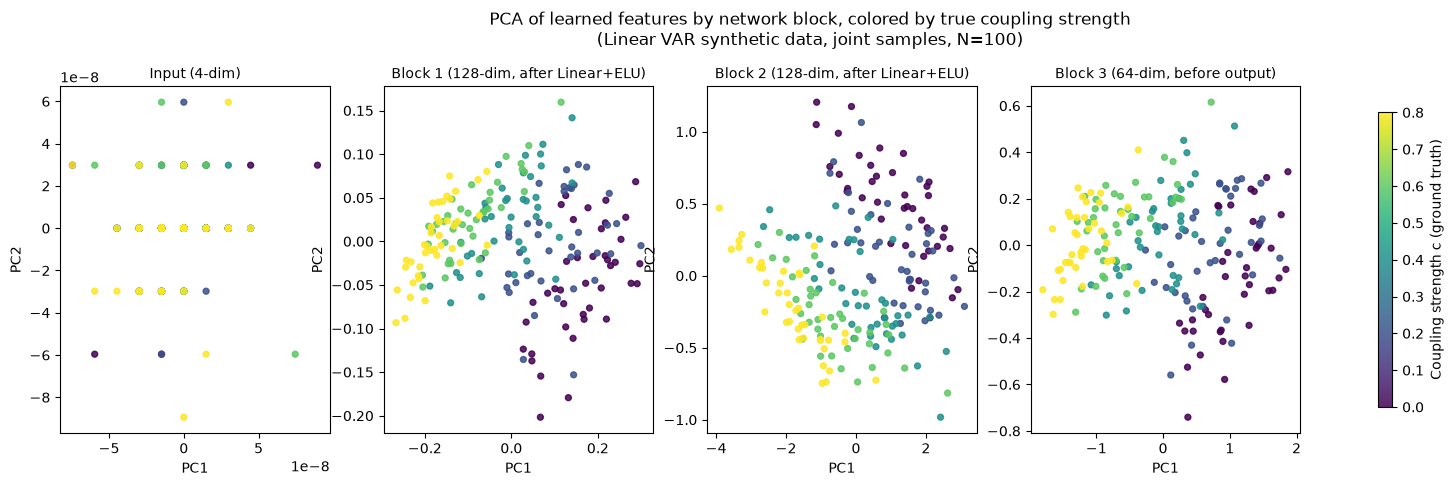

In [6]:
block_names = ['block0_input', 'block1', 'block2', 'block3']
block_titles = ['Input (4-dim)', 'Block 1 (128-dim, after Linear+ELU)',
                 'Block 2 (128-dim, after Linear+ELU)', 'Block 3 (64-dim, before output)']

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, bname, btitle in zip(axes, block_names, block_titles):
    X = np.stack([r[bname] for r in synth_records if r['kind'] == 'joint'])
    c_vals = np.array([r['coupling_c'] for r in synth_records if r['kind'] == 'joint'])
    Xp = PCA(n_components=2, random_state=0).fit_transform(X)
    sca = ax.scatter(Xp[:, 0], Xp[:, 1], c=c_vals, cmap='viridis', s=18, alpha=0.85)
    ax.set_title(btitle, fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.colorbar(sca, ax=axes, label='Coupling strength c (ground truth)', shrink=0.85)
fig.suptitle('PCA of learned features by network block, colored by true coupling strength\n'
             '(Linear VAR synthetic data, joint samples, N=100)', y=1.05)
plt.savefig(FIG_DIR / 'phase_t_pca_blocks_by_coupling.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Hình 2 — Joint vs marginal (đúng bản chất toán học của chặn dưới Donsker-Varadhan)

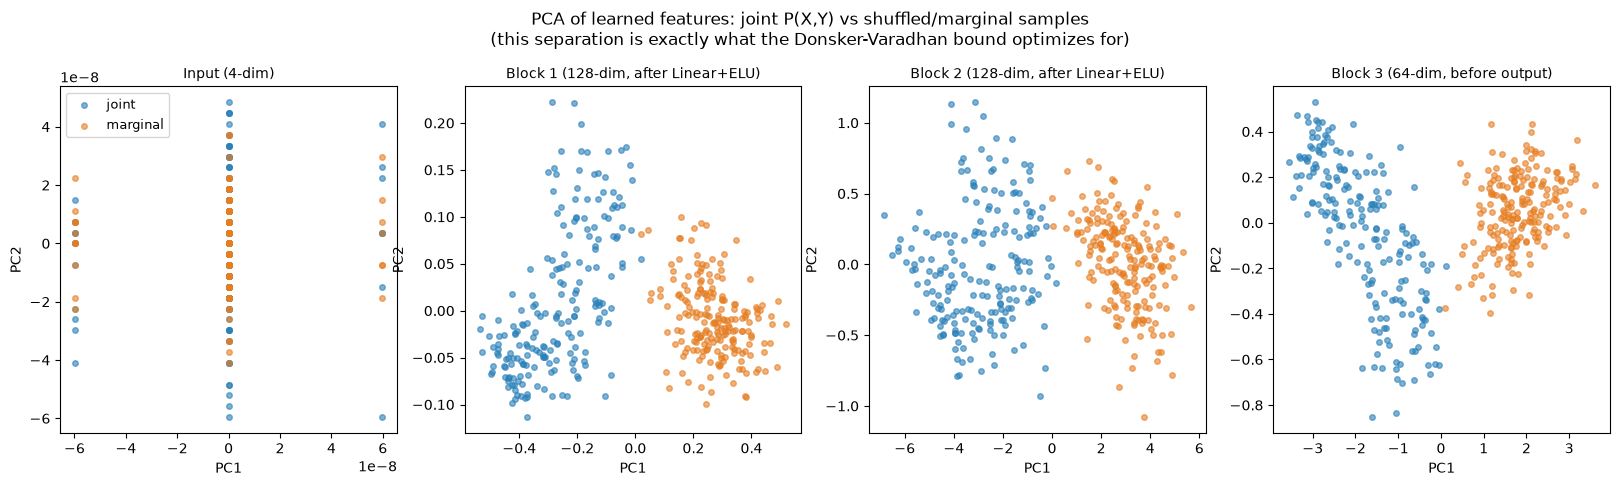

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, bname, btitle in zip(axes, block_names, block_titles):
    X = np.stack([r[bname] for r in synth_records])
    kinds = np.array([r['kind'] for r in synth_records])
    Xp = PCA(n_components=2, random_state=0).fit_transform(X)
    for kind, color in [('joint', '#2980b9'), ('marginal', '#e67e22')]:
        m = kinds == kind
        ax.scatter(Xp[m, 0], Xp[m, 1], c=color, s=16, alpha=0.6, label=kind)
    ax.set_title(btitle, fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=9)
fig.suptitle('PCA of learned features: joint P(X,Y) vs shuffled/marginal samples\n'
             '(this separation is exactly what the Donsker-Varadhan bound optimizes for)', y=1.05)
plt.savefig(FIG_DIR / 'phase_t_pca_blocks_joint_vs_marginal.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Hình 3 — Domain gap: chiếu dữ liệu THẬT vào PCA đã fit trên synthetic (không fit lại)

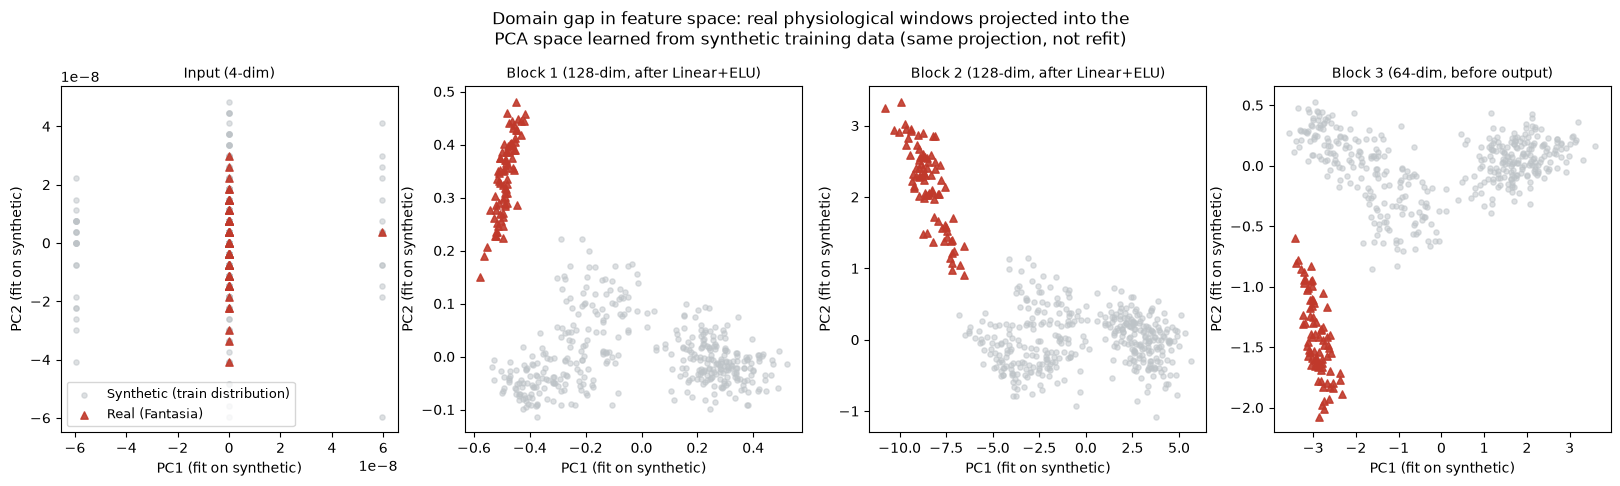

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, bname, btitle in zip(axes, block_names, block_titles):
    X_synth = np.stack([r[bname] for r in synth_records])
    pca = PCA(n_components=2, random_state=0).fit(X_synth)
    Xp_synth = pca.transform(X_synth)
    ax.scatter(Xp_synth[:, 0], Xp_synth[:, 1], c='#bdc3c7', s=14, alpha=0.5,
               label='Synthetic (train distribution)')

    if real_records:
        X_real = np.stack([r[bname] for r in real_records])
        Xp_real = pca.transform(X_real)
        ax.scatter(Xp_real[:, 0], Xp_real[:, 1], c='#c0392b', s=28, alpha=0.9,
                   marker='^', label='Real (Fantasia)')
    ax.set_title(btitle, fontsize=10)
    ax.set_xlabel('PC1 (fit on synthetic)'); ax.set_ylabel('PC2 (fit on synthetic)')
axes[0].legend(loc='best', fontsize=9)
fig.suptitle('Domain gap in feature space: real physiological windows projected into the\n'
             'PCA space learned from synthetic training data (same projection, not refit)', y=1.05)
plt.savefig(FIG_DIR / 'phase_t_pca_domain_gap.png', dpi=110, bbox_inches='tight')
plt.show()